# Task 1: ML Classification – Customer Churn Prediction
## Internspark AI Internship

## 1. Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
# Telco Customer Churn dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis

In [3]:
# Basic info
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
print('\nTarget distribution:')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


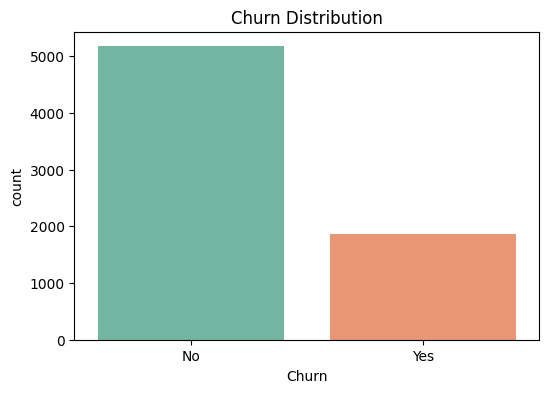

In [4]:
# Visualize target
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.show()

In [5]:
# Convert TotalCharges to numeric (has spaces as missing)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

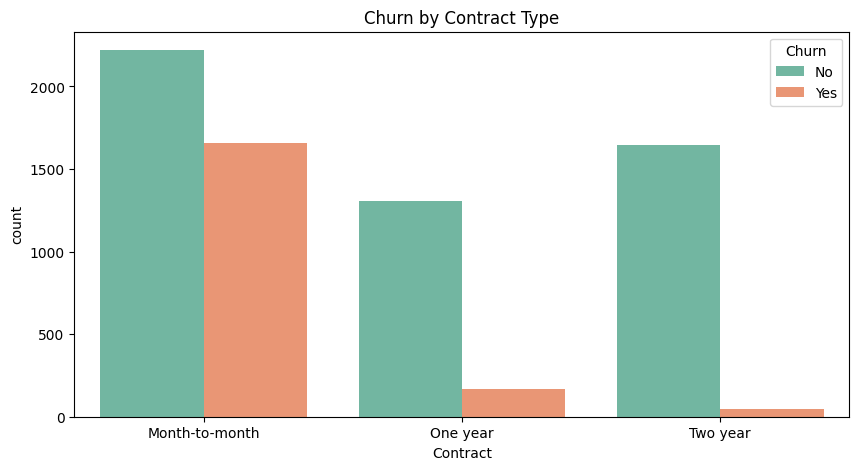

In [6]:
# Churn by contract type
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Contract Type')
plt.show()

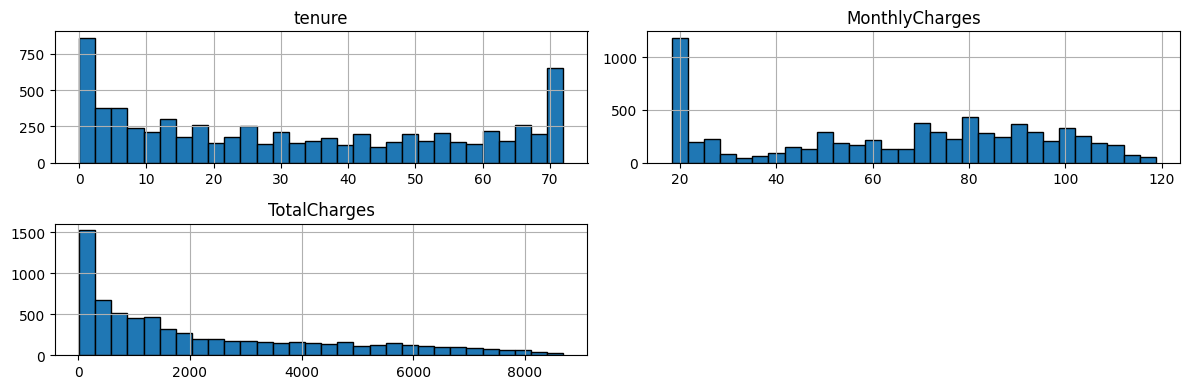

In [7]:
# Numeric feature distributions
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].hist(figsize=(12, 4), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [8]:
# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Identify categorical columns (excluding target)
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Label encode categoricals
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('All columns now numeric:')
print(df.dtypes.value_counts())

All columns now numeric:
int64      18
float64     2
Name: count, dtype: int64


In [9]:
# Define X and y
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('X shape:', X_scaled.shape)
print('y shape:', y.shape)

X shape: (7043, 19)
y shape: (7043,)


## 5. Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])
print('Train churn rate:', y_train.mean().round(3))
print('Test churn rate:', y_test.mean().round(3))

Train size: 5634
Test size: 1409
Train churn rate: 0.265
Test churn rate: 0.265


## 6. Model 1: Logistic Regression

In [11]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('Logistic Regression Results:')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy:  0.7991
Precision: 0.6426
Recall:    0.5481
F1 Score:  0.5916
ROC-AUC:   0.8402

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## 7. Cross-Validation (Logistic Regression)

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring='roc_auc')
print(f'CV ROC-AUC scores: {cv_scores}')
print(f'Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}')

CV ROC-AUC scores: [0.85428841 0.84284792 0.86529489 0.82412739 0.83304673]
Mean: 0.8439  |  Std: 0.0147


## 8. Model 2: Random Forest

In [13]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest Results:')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
Accuracy:  0.7956
Precision: 0.6463
Recall:    0.5080
F1 Score:  0.5689
ROC-AUC:   0.8358

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409



In [14]:
cv_scores_rf = cross_val_score(rf, X_scaled, y, cv=cv, scoring='roc_auc')
print(f'CV ROC-AUC scores: {cv_scores_rf}')
print(f'Mean: {cv_scores_rf.mean():.4f}  |  Std: {cv_scores_rf.std():.4f}')

CV ROC-AUC scores: [0.8556731  0.83792012 0.85725025 0.82167437 0.83529515]
Mean: 0.8416  |  Std: 0.0134


## 9. Model Comparison

In [15]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)]
})
print(comparison)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.799148   0.642633  0.548128  0.591631  0.840239
1        Random Forest  0.795600   0.646259  0.508021  0.568862  0.835772


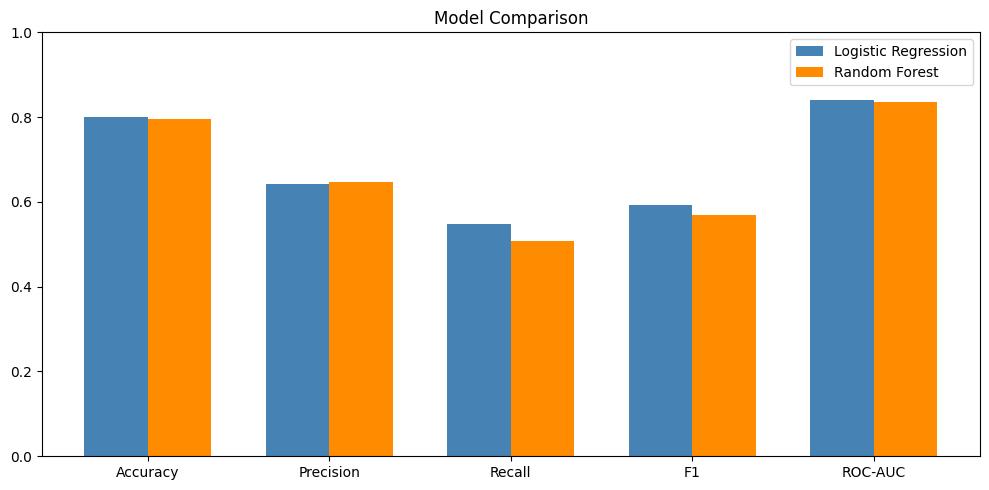

In [16]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
lr_scores = [accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr),
             recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr),
             roc_auc_score(y_test, y_prob_lr)]
rf_scores = [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
             recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf),
             roc_auc_score(y_test, y_prob_rf)]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## 10. ROC Curves

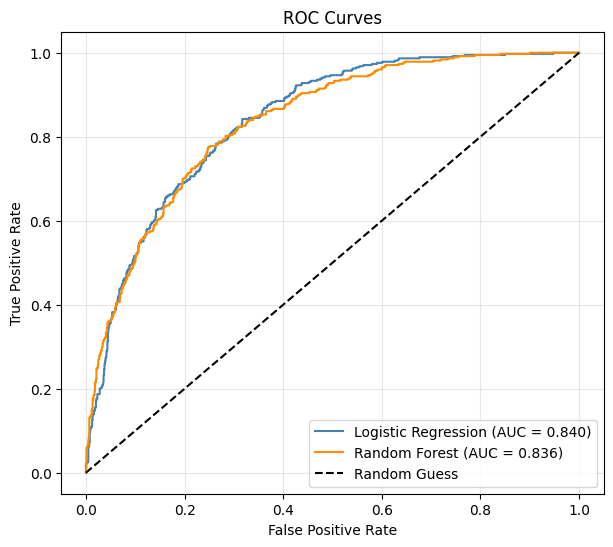

In [17]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})', color='steelblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. Confusion Matrices

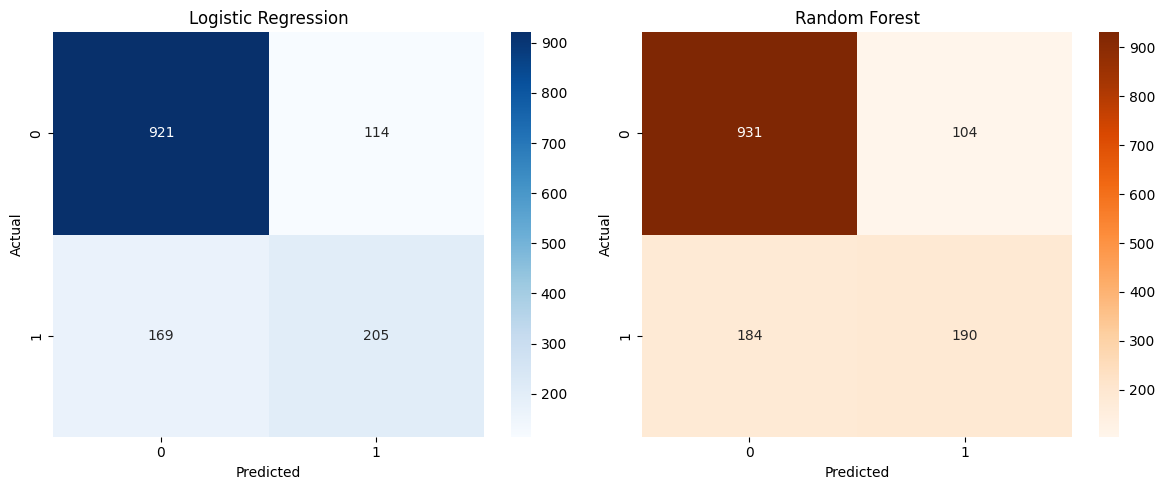

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=ax1, cmap='Blues')
ax1.set_title('Logistic Regression')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=ax2, cmap='Oranges')
ax2.set_title('Random Forest')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 12. Feature Importance (Random Forest)

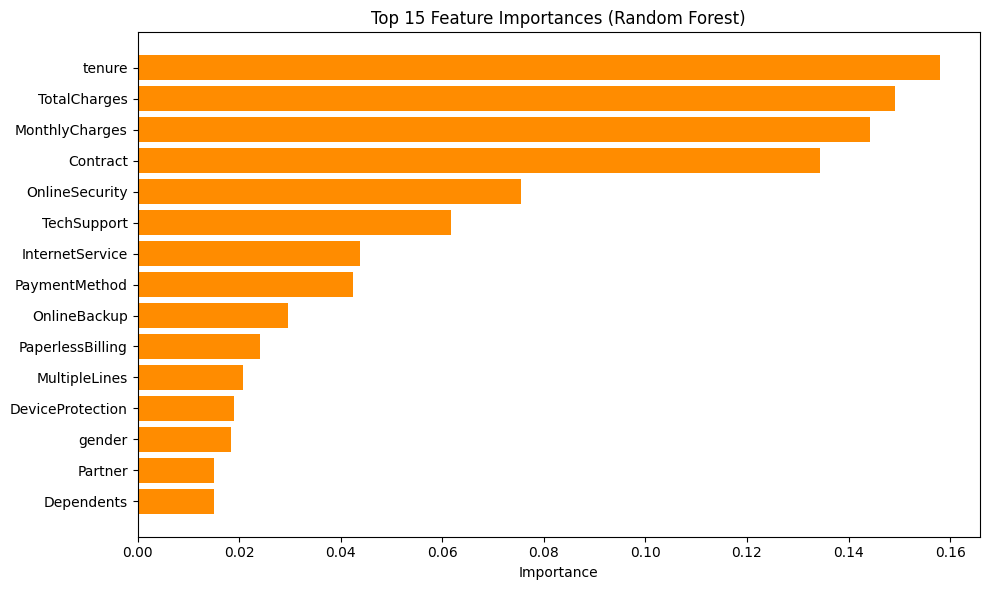

In [19]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][::-1], importances['Importance'][::-1], color='darkorange')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 13. Save Model for Task 4

In [20]:
import joblib

# Save the better model (pick based on results)
joblib.dump(rf, 'churn_model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
print('Model, scaler, and feature names saved.')

Model, scaler, and feature names saved.


## 14. Summary

- Logistic Regression and Random Forest both performed well on churn prediction.
- Logistic Regression slightly outperformed Random Forest (ROC-AUC: 0.8402 vs 0.8358, Accuracy: 0.7991 vs 0.7956), suggesting the decision boundary in this dataset is largely linear.
- Both models struggled with recall (0.51–0.55), meaning nearly half of churners are missed — a consequence of class imbalance (27% churn)
- Top predictive features: tenure, contract type, monthly charges, and total charges.
- 5-fold stratified cross-validation confirmed stable performance (mean ROC-AUC ~0.83).
- Model saved for Task 4 (Responsible AI & SHAP/LIME analysis).